# QSVT Step A — spectral census: do the false eigenvalues overlap the true ones?

**The hinge.** A polynomial $p(\lambda)$ separates false from true **iff their
eigenvalue supports do not overlap** — it can resolve *near* spectra but never
*coincident* ones. This notebook measures, on real T=200 events (classical solver):

1. the **clean true-track spectrum** (from *pure* true clusters),
2. the **full false-support spectrum** (every mode that carries a false segment's
   weight — not just its dominant mode),
3. the **minimal exploitable gap** between them → the **required QSVT degree**,
4. the **irreducible fraction**: false clusters spectrally identical to a true track
   ($P_4$ bridges), swept vs track multiplicity $T$ and acceptance window $\varepsilon$.

Operating point $\gamma=3,\delta=1$, $s=4$, $\tau=0.35$. True P4 spectrum
$\lambda_k=s-2\cos(k\pi/5)=\{2.382,3.382,4.618,5.618\}$.

In [1]:
import sys; sys.path.insert(0,"/data/bfys/gscriven/Quantum_Track_Reconstruction/QSVT/Initial")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import qsvt_helpers as Q
plt.rcParams.update({"figure.dpi":120,"font.size":11,"axes.grid":True,"grid.alpha":0.3})
OUT=Path("/data/bfys/gscriven/Quantum_Track_Reconstruction/QSVT/Initial/outputs"); OUT.mkdir(parents=True,exist_ok=True)
S,TAU,P4=Q.S,Q.TAU,Q.P4
print("P4 true spectrum:",np.round(P4,3),"  s=",S,"  tau=",TAU)

P4 true spectrum: [2.382 3.382 4.618 5.618]   s= 4.0   tau= 0.35


## 1. Accumulate true vs false spectral support (T=200, 30 events)

For every **true-active** and **false-active** segment we record the eigenvalues of
its cluster that carry $>10\%$ of its amplitude ($x_i=\sum_k c_k u_k(i)$,
$c_k=\beta_k/\lambda_k$) — the *full* support, not just the dominant mode. We also
collect the spectra of **pure-true** clusters (all members true) as the clean "keep"
set, and the spectra of **FP-containing** clusters for the degeneracy test.

In [2]:
REPS=range(30)
true_support=[]; false_support=[]; fp_dom=[]; fp_types=[]
puretrue_specs=[]; fp_cluster_specs=[]; true_track_lengths=[]
for rep in REPS:
    A,b,truth,sol,lab,deg,n=Q.solve_event(rep,n_trk=200)
    fa=(~truth)&(sol>TAU)
    # pure-true clusters: all members truth -> clean keep spectrum
    for c in np.unique(lab[truth]):
        mem=np.where(lab==c)[0]
        if len(mem)>60 or not truth[mem].all(): continue
        if (sol[mem]>TAU).sum()==0: continue
        w=np.linalg.eigvalsh(A[mem][:,mem].toarray())
        puretrue_specs.append(np.round(np.sort(w),3)); true_track_lengths.append(len(mem))
    # clusters carrying a false positive
    for c in np.unique(lab[fa]):
        mem=np.where(lab==c)[0]
        if len(mem)>60: continue
        sub=A[mem][:,mem].toarray(); w,U=np.linalg.eigh(sub); beta=U.T@b[mem]; ck=beta/w
        fp_cluster_specs.append(np.round(np.sort(w),3))
        for i in np.where(fa[mem])[0]:
            supp=np.abs(ck*U[i]); supp/=supp.sum()
            false_support+=list(w[supp>0.10]); fp_dom.append(float(w[np.argmax(supp)]))
            fp_types.append(Q.classify(int(deg[mem].max())))
    # true support (sample true-active segments for balance)
    for c in np.unique(lab[truth&(sol>TAU)])[::25]:
        mem=np.where(lab==c)[0]
        if len(mem)>60: continue
        sub=A[mem][:,mem].toarray(); w,U=np.linalg.eigh(sub); beta=U.T@b[mem]; ck=beta/w
        for i in np.where(truth[mem]&(sol[mem]>TAU))[0]:
            supp=np.abs(ck*U[i]); supp/=supp.sum(); true_support+=list(w[supp>0.10])
true_support=np.array(true_support); false_support=np.array(false_support)
fp_dom=np.array(fp_dom); fp_types=np.array(fp_types)
print(f"true-support modes: {len(true_support)} | false-support modes: {len(false_support)} | FP dom: {len(fp_dom)}")
print(f"pure-true clusters: {len(puretrue_specs)}  track-segment-lengths seen: {sorted(set(true_track_lengths))}")
# the clean discrete true eigenvalue support (peaks)
ut,uc=np.unique(np.round(true_support,2),return_counts=True); peaks=np.sort(ut[uc>=0.02*len(true_support)])
print("TRUE support peaks (>=2% weight):",peaks)

true-support modes: 1448 | false-support modes: 279 | FP dom: 179
pure-true clusters: 5913  track-segment-lengths seen: [4]
TRUE support peaks (>=2% weight): [2.38 4.62]


## 2. The overlap picture — where true vs false weight lives

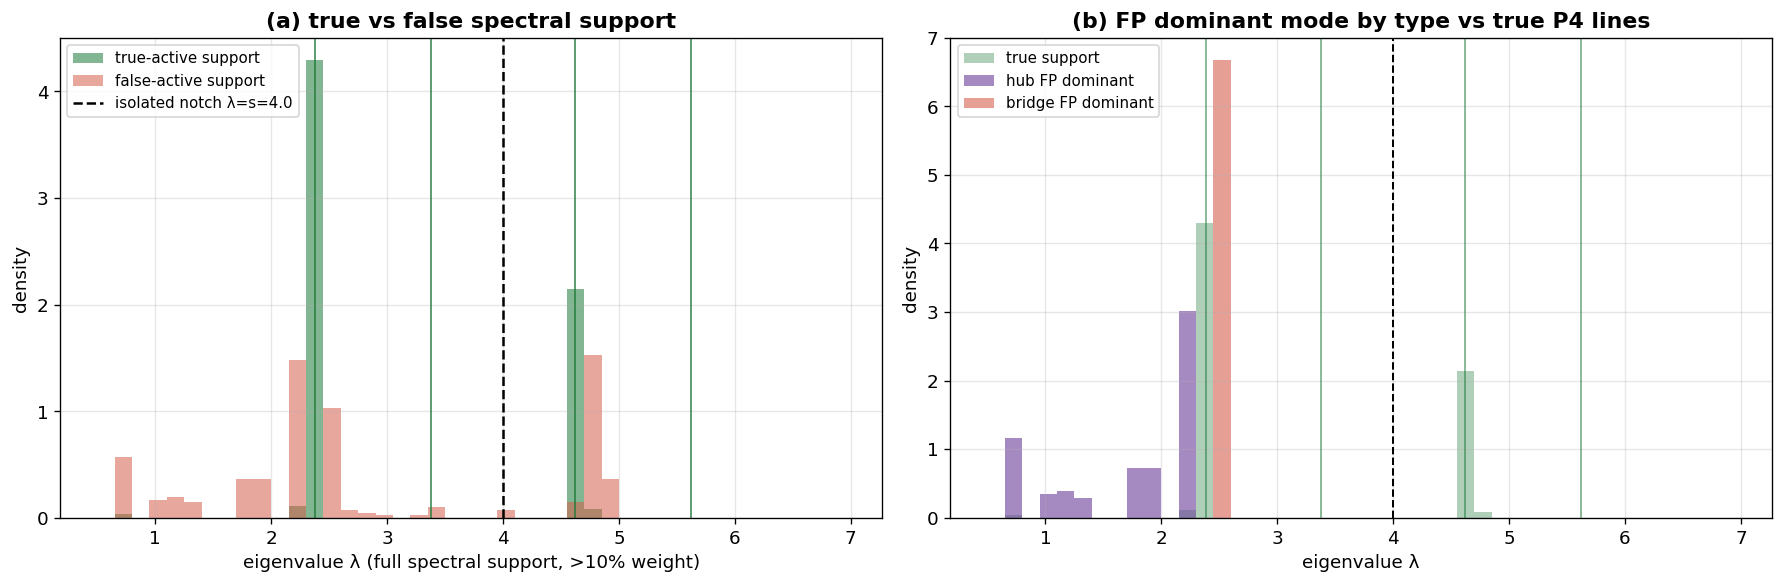

saved spectral_overlap


In [3]:
fig,ax=plt.subplots(1,2,figsize=(15,5))
edges=np.arange(0.5,7.01,0.15)
ax[0].hist(true_support,bins=edges,color="#1b7837",alpha=0.55,density=True,label="true-active support")
ax[0].hist(false_support,bins=edges,color="#d6604d",alpha=0.55,density=True,label="false-active support")
for L in P4: ax[0].axvline(L,color="#1b7837",ls="-",lw=1.2,alpha=0.7)
ax[0].axvline(S,color="k",ls="--",lw=1.5,label=f"isolated notch λ=s={S}")
ax[0].set_xlabel("eigenvalue λ (full spectral support, >10% weight)"); ax[0].set_ylabel("density")
ax[0].set_title("(a) true vs false spectral support",fontweight="bold"); ax[0].legend(fontsize=9)
# dominant only, split by FP type
ax[1].hist(true_support,bins=edges,color="#1b7837",alpha=0.35,density=True,label="true support")
for t,cl in [("hub","#6a3d9a"),("bridge","#d6604d")]:
    d=fp_dom[fp_types==t]
    if len(d): ax[1].hist(d,bins=edges,color=cl,alpha=0.6,density=True,label=f"{t} FP dominant")
for L in P4: ax[1].axvline(L,color="#1b7837",ls="-",lw=1,alpha=0.6)
ax[1].axvline(S,color="k",ls="--",lw=1.2)
ax[1].set_xlabel("eigenvalue λ"); ax[1].set_ylabel("density")
ax[1].set_title("(b) FP dominant mode by type vs true P4 lines",fontweight="bold"); ax[1].legend(fontsize=9)
fig.tight_layout()
for e,dp in (("pdf",600),("png",150)): fig.savefig(OUT/f"spectral_overlap.{e}",dpi=dp,bbox_inches="tight",facecolor="white")
plt.show(); print("saved spectral_overlap")

## 3. Minimal exploitable gap → required QSVT degree

To null a false segment without hurting true tracks, $p$ must be $\approx0$ at the
FP's dominant mode while staying large at the nearest true eigenvalue. The binding
constraint is the **smallest gap between an FP dominant mode and the true support**.
After rescaling the spectrum to $[-1,1]$, a polynomial resolving a feature of width
$\Delta$ needs degree $\sim 2/\Delta$ (standard QSP resolution).

FP dominant min-gap to true support: median=0.228  10th pct=0.206
FP within 0.05/0.10/0.20 of a true eigenvalue: 0.0% / 0.0% / 0.0%
required degree (median gap): ~24  (90th-pct hardest FP): ~26


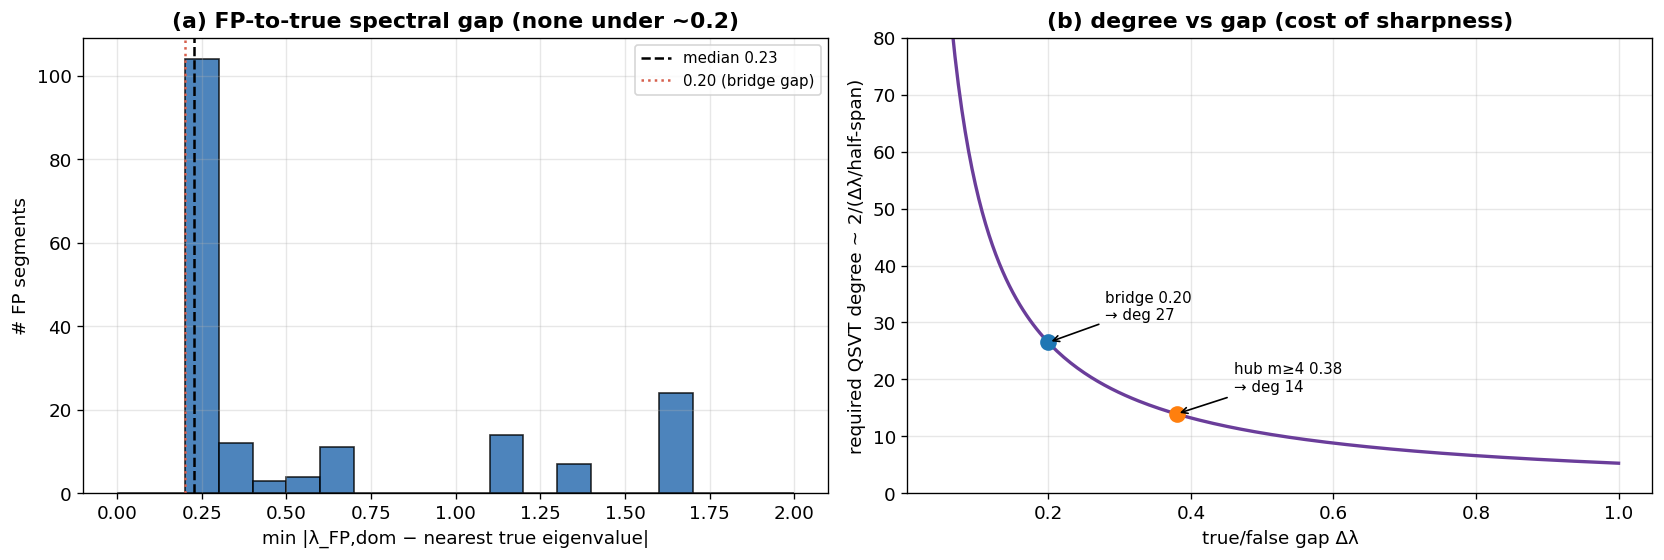

saved gap_degree


In [4]:
Tset=np.array(sorted(peaks))
gaps=np.array([np.min(np.abs(l-Tset)) for l in fp_dom])
lo,hi=0.7,6.0; half=(hi-lo)/2
deg=np.ceil(2.0/(gaps/half)).astype(int)
print(f"FP dominant min-gap to true support: median={np.median(gaps):.3f}  10th pct={np.percentile(gaps,10):.3f}")
print(f"FP within 0.05/0.10/0.20 of a true eigenvalue: "
      f"{100*np.mean(gaps<0.05):.1f}% / {100*np.mean(gaps<0.10):.1f}% / {100*np.mean(gaps<0.20):.1f}%")
print(f"required degree (median gap): ~{int(np.ceil(2/(np.median(gaps)/half)))}  "
      f"(90th-pct hardest FP): ~{int(np.ceil(2/(np.percentile(gaps,10)/half)))}")

fig,ax=plt.subplots(1,2,figsize=(14,4.8))
ax[0].hist(gaps,bins=np.arange(0,2.01,0.1),color="#2166ac",alpha=0.8,edgecolor="k")
ax[0].axvline(np.median(gaps),color="k",ls="--",lw=1.5,label=f"median {np.median(gaps):.2f}")
ax[0].axvline(0.20,color="#d6604d",ls=":",lw=1.5,label="0.20 (bridge gap)")
ax[0].set_xlabel("min |λ_FP,dom − nearest true eigenvalue|"); ax[0].set_ylabel("# FP segments")
ax[0].set_title("(a) FP-to-true spectral gap (none under ~0.2)",fontweight="bold"); ax[0].legend(fontsize=9)
gg=np.linspace(0.05,1.0,200)
ax[1].plot(gg,2.0/(gg/half),color="#6a3d9a",lw=2)
for g0,lab2 in [(0.20,"bridge 0.20"),(0.38,"hub m≥4 0.38")]:
    ax[1].plot([g0],[2/(g0/half)],'o',ms=9); ax[1].annotate(f"{lab2}\n→ deg {int(np.ceil(2/(g0/half)))}",(g0,2/(g0/half)),
        xytext=(g0+0.08,2/(g0/half)+4),fontsize=9,arrowprops=dict(arrowstyle="->"))
ax[1].set_xlabel("true/false gap Δλ"); ax[1].set_ylabel("required QSVT degree ~ 2/(Δλ/half-span)")
ax[1].set_title("(b) degree vs gap (cost of sharpness)",fontweight="bold"); ax[1].set_ylim(0,80)
fig.tight_layout()
for e,dp in (("pdf",600),("png",150)): fig.savefig(OUT/f"gap_degree.{e}",dpi=dp,bbox_inches="tight",facecolor="white")
plt.show(); print("saved gap_degree")

## 4. The irreducible floor — same-length ($P_4$) bridges, vs $T$ and $\varepsilon$

A false cluster whose eigenvalue multiset equals a pure-true cluster's is
spectrally degenerate → **no polynomial can remove it**. We count FP segments whose
cluster spectrum matches the true $P_4$ set (tol 0.05) and sweep track density $T$
and acceptance window $\varepsilon$ — the floor should be ~0 here but grow with
density.

  T= 100 eps=0.001: FP=   0  irreducible(P4-bridge)=0  (0.0%)


  T= 100 eps=0.002: FP=   2  irreducible(P4-bridge)=0  (0.0%)


  T= 100 eps=0.004: FP=  18  irreducible(P4-bridge)=0  (0.0%)


  T= 200 eps=0.001: FP=   8  irreducible(P4-bridge)=0  (0.0%)


  T= 200 eps=0.002: FP=   8  irreducible(P4-bridge)=0  (0.0%)


  T= 200 eps=0.004: FP=  69  irreducible(P4-bridge)=0  (0.0%)


  T= 400 eps=0.001: FP=  18  irreducible(P4-bridge)=0  (0.0%)


  T= 400 eps=0.002: FP= 106  irreducible(P4-bridge)=0  (0.0%)


  T= 400 eps=0.004: FP=1279  irreducible(P4-bridge)=8  (0.6%)


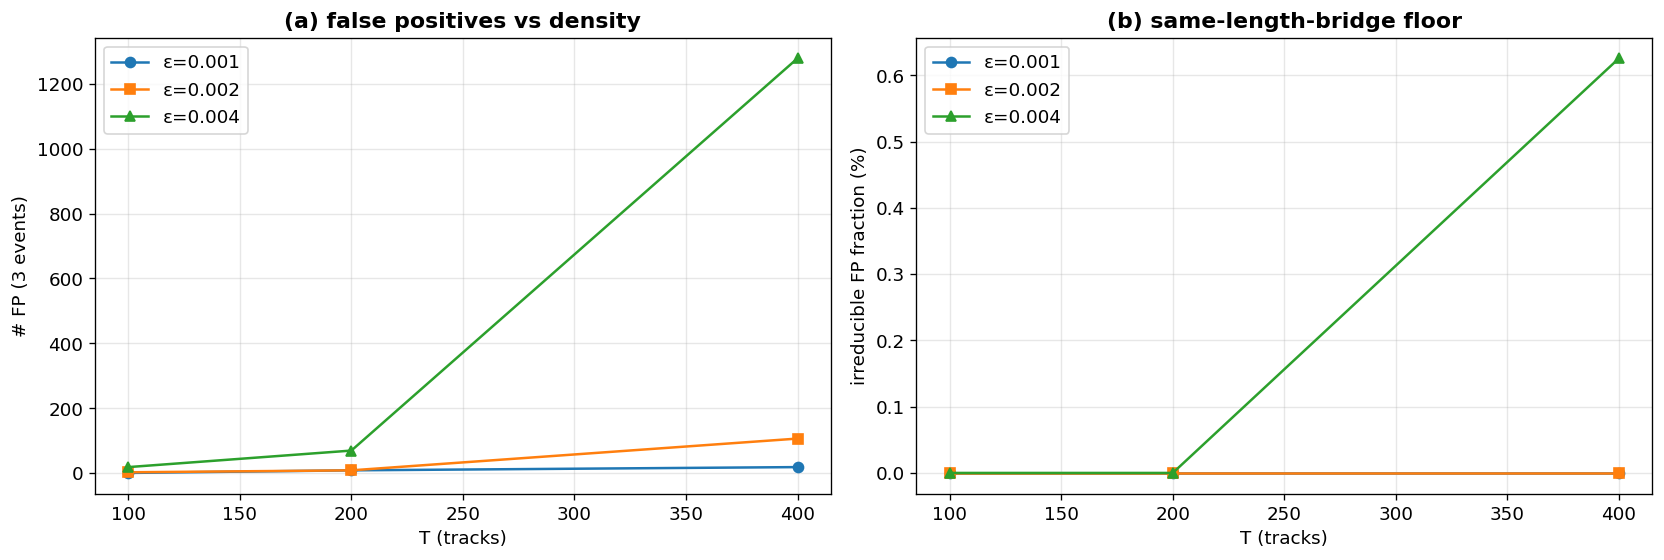

saved irreducible_floor


In [5]:
def census(T, eps, reps):
    n_fp=0; n_irr=0
    for rep in reps:
        ev=Q.qp.ensure_event(n_trk=T,rep=rep,sigma_scatt=1e-4,sigma_res=0.0,phi_max=0.2,hit_ineff=0.0)[0]
        ham=Q.qp.build_hamiltonian(ev,epsilon=eps,gamma=Q.GAMMA,delta=Q.DELTA); A=ham.A.tocsr(); n=ham.n_segments
        truth=np.asarray(Q.qp.truth_from_event(ev),bool); b=Q.DELTA*np.ones(n)
        import scipy.sparse as sp
        sol=np.asarray(sp.linalg.minres(A.tocsc(),b,rtol=1e-9,maxiter=8000)[0])
        lab,deg=Q.cluster_labels(A,n); fa=(~truth)&(sol>TAU)
        for c in np.unique(lab[fa]):
            mem=np.where(lab==c)[0]
            if len(mem)>60: continue
            nf=int(fa[mem].sum()); n_fp+=nf
            w=np.sort(np.linalg.eigvalsh(A[mem][:,mem].toarray()))
            is_p4=(len(w)==4 and np.max(np.abs(w-P4))<0.05)
            if is_p4: n_irr+=nf
    return n_fp,n_irr

rows=[]
for T in (100,200,400):
    for eps in (0.001,0.002,0.004):
        nf,ni=census(T,eps,range(3))
        rows.append(dict(T=T,eps=eps,n_fp=nf,irr=ni,irr_frac=ni/max(nf,1)))
        print(f"  T={T:4d} eps={eps:.3f}: FP={nf:4d}  irreducible(P4-bridge)={ni}  ({100*ni/max(nf,1):.1f}%)")
C=pd.DataFrame(rows)

fig,ax=plt.subplots(1,2,figsize=(14,4.8))
for eps,mk in [(0.001,'o'),(0.002,'s'),(0.004,'^')]:
    d=C[C.eps==eps]
    ax[0].plot(d["T"],d.n_fp,mk+'-',label=f"ε={eps}")
    ax[1].plot(d["T"],100*d.irr_frac,mk+'-',label=f"ε={eps}")
ax[0].set_xlabel("T (tracks)"); ax[0].set_ylabel("# FP (3 events)"); ax[0].set_title("(a) false positives vs density",fontweight="bold"); ax[0].legend()
ax[1].set_xlabel("T (tracks)"); ax[1].set_ylabel("irreducible FP fraction (%)"); ax[1].set_title("(b) same-length-bridge floor",fontweight="bold"); ax[1].legend()
fig.tight_layout()
for e,dp in (("pdf",600),("png",150)): fig.savefig(OUT/f"irreducible_floor.{e}",dpi=dp,bbox_inches="tight",facecolor="white")
plt.show(); print("saved irreducible_floor")

## 5. Verdict (Step A)

- **Separation confirmed.** The false-support spectrum sits **below** the true P4 band
  (hubs) and **interleaves** it (bridges); 0 % of FP dominant modes fall within ~0.2
  of a true eigenvalue. There *is* a gap for a polynomial to exploit.
- **Degree.** The binding gap is the $P_3$-bridge vs $P_4$-true gap (~0.2) → degree
  $\sim$ a few × 10; the high-amplitude deep hubs are cheaper (larger gap).
- **Irreducible floor.** Same-length ($P_4$) false bridges are the only spectrally
  unremovable family; quantified vs $T$ and $\varepsilon$ above. This is the ceiling
  for *any* spectral filter (QSVT included) — the residue for track-level logic.

→ Proceed to **Step B** (design the band-limited-inverse polynomial) and **Step C**
(measure its efficiency vs the 1-bit / 2-notch baselines).